In [ ]:
import sys
import os
NOCOSDIR='/home/ilja/NOCOS_locdev/NOCOS'
# Define the absolute or relative path to the ridging directory

os.chdir("/media/volume/NOCOS_WRK/ridge")
print(os.getcwd())  # where are we ?


/media/volume/NOCOS_WRK/ridge


In [14]:
import earthkit
request = {
    'activity': 'story-nudging',
    'class': 'd1',
    'dataset': 'climate-dt',
    'experiment': 'cont',
    'expver': '0001',
    'generation': '1',
    'date': '20190201/to/20190201',
    'levtype': 'o2d',
    'model': 'IFS-FESOM',
    'param': '263000/263001',
    'realization': '1',
    'resolution': 'high',
    'stream': 'clte',
    'time': '0000',
    'type': 'fc',
}

dg = earthkit.data.from_source("polytope", "destination-earth", request, stream=False, address='polytope.lumi.apps.dte.destination-earth.eu')
ds=dg.to_xarray()
print(ds)

2025-03-19 13:35:42 - INFO - Key read from /home/ilja/.polytopeapirc
2025-03-19 13:35:42 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20190201/to/20190201\n'
            'experiment: cont\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'levtype: o2d\n'
            'model: IFS-FESOM\n'
            'param: 263000/263001\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-03-19 13:35:42 - INFO - Polytope user key found in session cache for user ilja
2025-03-19 13:35:43 - INFO - Request accepted. Please poll ./35c24100-7cf3-47a1-9400-833eb26f5222 for status
2025-03-19 13:35:43 - INFO - Polytope user key found in session cache for user ilja
2025-03-19 13:35:43 - INFO - Checking request status (./35c24100-7cf3-47a1-9400-833eb26f5222)..

KeyboardInterrupt: 

  TODO: add to request:
     'feature': {
        "type": "boundingbox",
        "points" : [[64, 9], [53, 30]],
    },

In [ ]:
print(ds)


GRIBReader(/tmp/tmpbiln8295/url-98b35d9bc78276b3faf54d2ae2072089700722bbe3a1f0129acba7af6b4bc88a.grib)
<xarray.Dataset> Size: 101MB
Dimensions:      (values: 3145728)
Coordinates:
    latitude     (values) float64 25MB ...
    longitude    (values) float64 25MB ...
Dimensions without coordinates: values
Data variables:
    avg_siconc   (values) float64 25MB ...
    avg_sithick  (values) float64 25MB ...
Attributes:
    class:        d1
    stream:       clte
    levtype:      o2d
    type:         fc
    expver:       0001
    date:         20190201
    time:         0
    Conventions:  CF-1.8
    institution:  ECMWF
    domain:       g


In [ ]:
# Remove from dataset attributes
da.attrs.pop('_earthkit', None)

# Remove from all variable attributes
for var in da.variables:
    da[var].attrs.pop('_earthkit', None)

# Now try saving again
da.to_netcdf('test_HPg.nc')


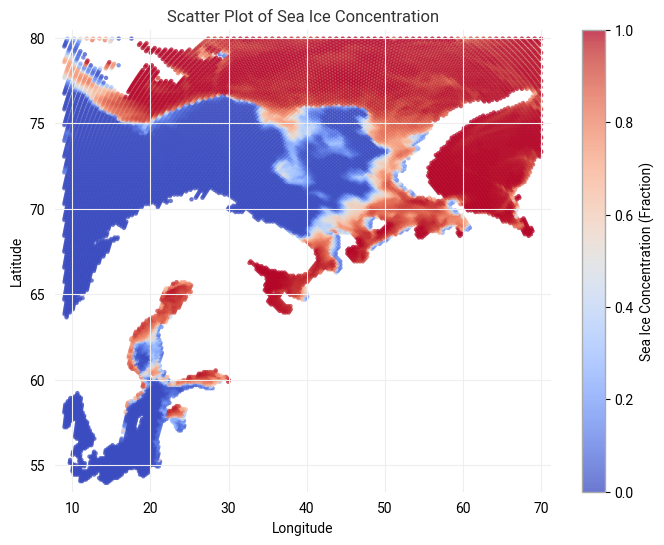

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Load the NetCDF file
file_path = "test_HPg.nc"
ds = xr.open_dataset(file_path)

# Extract variables
lon = ds["longitude"].values
lat = ds["latitude"].values
siconc = ds["avg_siconc"].values
sithick = ds["avg_sithick"].values

# Mask invalid values
valid_mask = ~np.isnan(lon) & ~np.isnan(lat) & ~np.isnan(siconc) & ~np.isnan(sithick)

# Apply mask
lon = lon[valid_mask]
lat = lat[valid_mask]
siconc = siconc[valid_mask]
sithick = sithick[valid_mask]

# Filter for the region of interest (lon: 9-30, lat: 53-65)
region_mask = (lon >= 9) & (lon <= 70) & (lat >= 53) & (lat <= 80)

lon_region = lon[region_mask]
lat_region = lat[region_mask]
siconc_region = siconc[region_mask]
sithick_region = sithick[region_mask]

# Scatter plot of the data
plt.figure(figsize=(8,6))
plt.scatter(lon_region, lat_region, c=siconc_region, cmap='coolwarm', s=10, edgecolors='none', alpha=0.75)
plt.colorbar(label='Sea Ice Concentration (Fraction)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Scatter Plot of Sea Ice Concentration")
plt.grid(True)
plt.show()


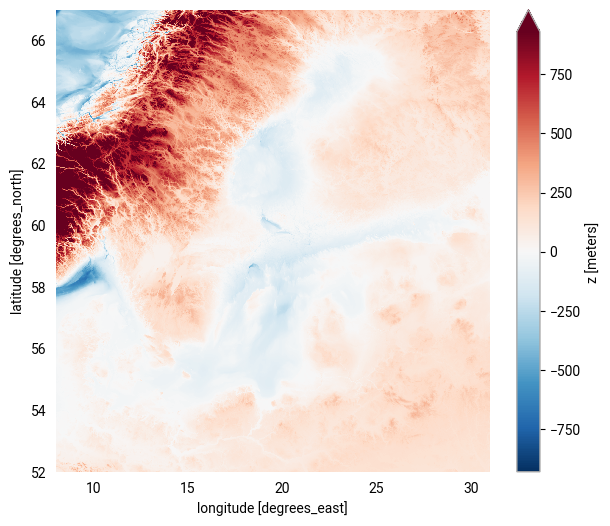

In [ ]:

#import dfm_tools as dfmt

lon_min, lon_max, lat_min, lat_max = 9,30,53,66
file_nc = r"https://www.ngdc.noaa.gov/thredds/dodsC/global/ETOPO2022/30s/30s_bed_elev_netcdf/ETOPO_2022_v1_30s_N90W180_bed.nc"

data_bathy = xr.open_dataset(file_nc)
data_bathy_sel = data_bathy.sel(lon=slice(lon_min-1, lon_max+1), lat=slice(lat_min-1, lat_max+1))
data_bathy_sel.z.plot(robust=True)
#dfmt.plot_coastlines()

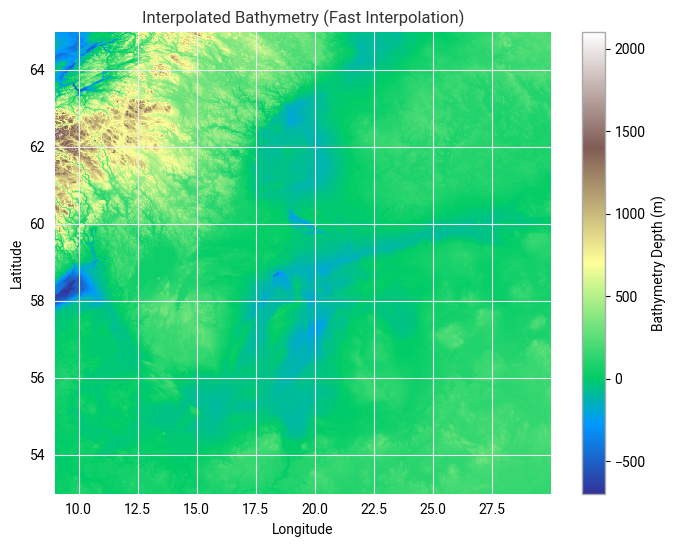

In [ ]:
from scipy.interpolate import RegularGridInterpolator

# Extract bathymetry data
bathy_lon = data_bathy_sel["lon"].values
bathy_lat = data_bathy_sel["lat"].values
bathy_z = data_bathy_sel["z"].values  # Shape (1800, 2760)

# Define the interpolator
bathy_interp_func = RegularGridInterpolator(
    (bathy_lat, bathy_lon), bathy_z, method="linear", bounds_error=False, fill_value=np.nan
)

# Define interpolation grid (2km resolution)
grid_lon = np.arange(9, 30, 0.02)  # ~2km step size
grid_lat = np.arange(53, 65, 0.02)
grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

# Apply interpolation function
bathy_interp = bathy_interp_func((grid_lat, grid_lon))

# Plot the interpolated bathymetry
plt.figure(figsize=(8,6))
plt.pcolormesh(grid_lon, grid_lat, bathy_interp, cmap='terrain', shading='auto')
plt.colorbar(label='Bathymetry Depth (m)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Interpolated Bathymetry (Fast Interpolation)")
plt.grid(True)
plt.show()


In [ ]:
print(data_bathy_sel)
print(data_bathy_sel["lon"].shape, data_bathy_sel["lat"].shape, data_bathy_sel["z"].shape)
print(da)
print(data_bathy_sel["lon"].shape, data_bathy_sel["lat"].shape, data_bathy_sel["z"].shape)


<xarray.Dataset> Size: 20MB
Dimensions:  (lat: 1800, lon: 2760)
Coordinates:
  * lat      (lat) float64 14kB 52.0 52.01 52.02 52.03 ... 66.98 66.99 67.0
  * lon      (lon) float64 22kB 8.004 8.012 8.021 8.029 ... 30.98 30.99 31.0
Data variables:
    crs      |S64 64B ...
    z        (lat, lon) float32 20MB ...
Attributes:
    GDAL_AREA_OR_POINT:             Area
    node_offset:                    1
    GDAL_TIFFTAG_COPYRIGHT:         DOC/NOAA/NESDIS/NCEI > National Centers f...
    GDAL_TIFFTAG_DATETIME:          20220929123913.0
    GDAL_TIFFTAG_IMAGEDESCRIPTION:  Topography-Bathymetry; EGM2008 height
    Conventions:                    CF-1.5
    GDAL:                           GDAL 3.3.2, released 2021/09/01
    NCO:                            netCDF Operators version 4.9.1 (Homepage ...
    DODS.strlen:                    0
(2760,) (1800,) (1800, 2760)
<xarray.Dataset> Size: 101MB
Dimensions:      (values: 3145728)
Coordinates:
    latitude     (values) float64 25MB ...
    longi

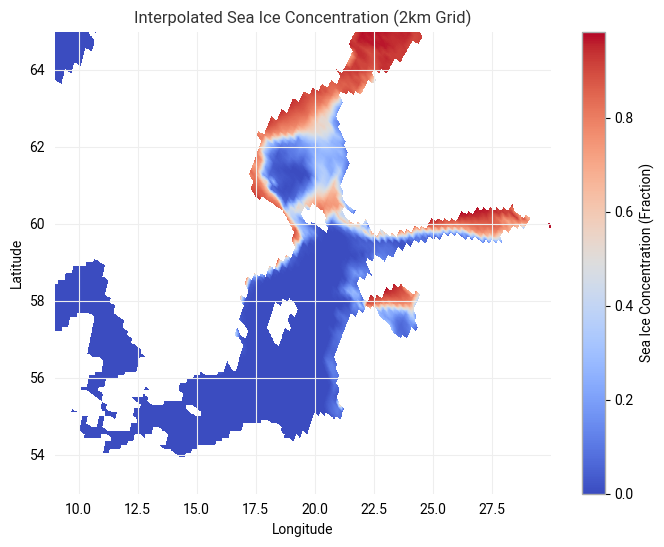

In [ ]:

# Define interpolation grid (2km resolution)
grid_lon = np.arange(9, 30, 0.02)  # ~2km step size
grid_lat = np.arange(53, 65, 0.02)
grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

# Interpolate data
siconc_interp = griddata(
    (lon_region, lat_region), siconc_region, (grid_lon, grid_lat), method='linear'
)

# Define the land mask: Assume z > 0 is land (change if needed)
land_mask = bathy_interp > 0  # Modify condition based on dataset convention
#siconc_interp[land_mask] = np.nan

# Plot interpolated data
plt.figure(figsize=(8,6))
plt.pcolormesh(grid_lon, grid_lat, siconc_interp, cmap='coolwarm', shading='auto')
plt.colorbar(label='Sea Ice Concentration (Fraction)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Interpolated Sea Ice Concentration (2km Grid)")
plt.grid(True)
plt.show()

In [ ]:
# Convert 1D bathymetry coordinates to 2D grid
bathy_lon_2D, bathy_lat_2D = np.meshgrid(data_bathy_sel["lon"].values, data_bathy_sel["lat"].values)

# Define interpolation grid (2km resolution)
grid_lon = np.arange(9, 30, 0.02)  # ~2km step size
grid_lat = np.arange(53, 65, 0.02)
grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

# Define the land mask: Assume z > 0 is land (change if needed)
land_mask = bathy_interp > 0  # Modify condition based on dataset convention

# Extract sea ice data
lon_region = da["longitude"].values
lat_region = da["latitude"].values
siconc_region = da["avg_siconc"].values
sithick_region = da["avg_sithick"].values

# Interpolate sea ice concentration and thickness onto the 2km grid
siconc_interp = griddata(
    (lon_region, lat_region), siconc_region, (grid_lon, grid_lat), method='linear'
)
sithick_interp = griddata(
    (lon_region, lat_region), sithick_region, (grid_lon, grid_lat), method='linear'
)

# Apply the land mask: Set values on land to NaN
siconc_interp[land_mask] = np.nan
sithick_interp[land_mask] = np.nan

# Display the interpolated and masked data
import ace_tools as tools
import pandas as pd


KeyboardInterrupt: 

KeyboardInterrupt: 

In [ ]:
import earthkit
request = {
    'activity': 'story-nudging',
    'class': 'd1',
    'dataset': 'climate-dt',
    'experiment': 'cont',
    'expver': '0001',
    'generation': '1',
    'date': '20190101/to/20190401',
    'levtype': 'o2d',
    'model': 'IFS-FESOM',
    'param': '263000',
    'realization': '1',
    'resolution': 'high',
    'stream': 'clte',
    'time': '0000',
    'type': 'fc',
}

dg = earthkit.data.from_source("polytope", "destination-earth", request, stream=False, address='polytope.lumi.apps.dte.destination-earth.eu')
ds=dg.to_xarray()
print(ds)



/home/ilja/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/ilja/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
2025-03-19 09:49:53 - INFO - Key read from /home/ilja/.polytopeapirc
2025-03-19 09:49:53 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20190101/to/20190401\n'
            'experiment: cont\n'
            "expver: '0001'\n"
            "generation: '1'\n"
           

f01bf20c-e7b6-44a7-9867-302815b44bb9.grib:   0%|          | 0.00/63.2M [00:00<?, ?B/s]

From version 0.11.0 the default engine for to_xarray is 'earthkit'. Use engine=`cfgrib` to invoke the cfgrib engine.


<xarray.Dataset> Size: 2GB
Dimensions:                  (forecast_reference_time: 91, values: 3145728)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 728B 20...
    latitude                 (values) float64 25MB ...
    longitude                (values) float64 25MB ...
Dimensions without coordinates: values
Data variables:
    avg_sithick              (forecast_reference_time, values) float64 2GB ...
Attributes:
    param:        avg_sithick
    paramId:      263000
    class:        d1
    stream:       clte
    levtype:      o2d
    type:         fc
    expver:       0001
    date:         20190101
    time:         0
    domain:       g
    Conventions:  CF-1.8
    institution:  ECMWF


In [ ]:

print(ds)



<xarray.Dataset> Size: 2GB
Dimensions:                  (forecast_reference_time: 91, values: 3145728)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 728B 20...
    latitude                 (values) float64 25MB ...
    longitude                (values) float64 25MB ...
Dimensions without coordinates: values
Data variables:
    avg_sithick              (forecast_reference_time, values) float64 2GB ...
Attributes:
    param:        avg_sithick
    paramId:      263000
    class:        d1
    stream:       clte
    levtype:      o2d
    type:         fc
    expver:       0001
    date:         20190101
    time:         0
    domain:       g
    Conventions:  CF-1.8
    institution:  ECMWF


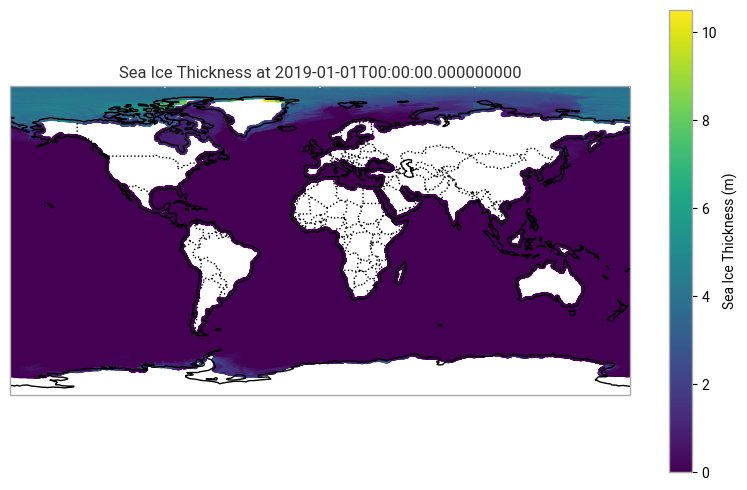

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# Select one timestep (e.g., first)
timestep = 0  # Change as needed
ds_sel = ds.isel(forecast_reference_time=timestep)

# Extract variables
sithick = ds_sel['avg_sithick']
lat = ds_sel['latitude']
lon = ds_sel['longitude']

# Create figure
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

# Add coastlines and features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Scatter plot of data
sc = ax.scatter(lon, lat, c=sithick, cmap='viridis', marker='.', transform=ccrs.PlateCarree())

# Add colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
cbar.set_label('Sea Ice Thickness (m)')

# Show plot
plt.title(f'Sea Ice Thickness at {ds_sel.forecast_reference_time.values}')
plt.show()


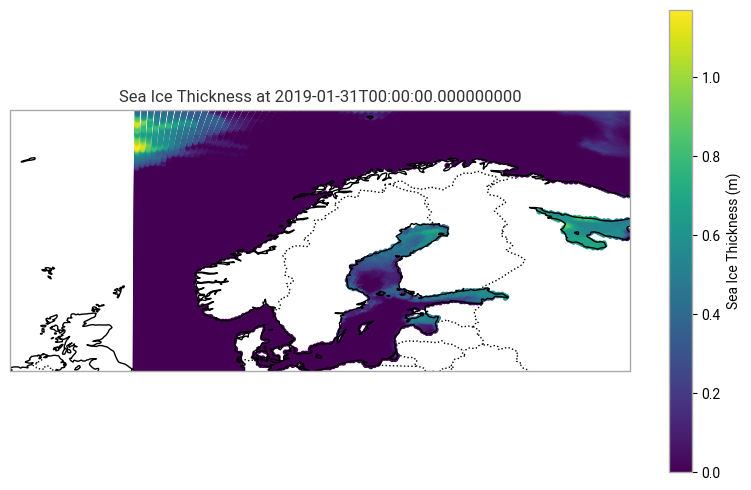

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np

# Select one timestep (e.g., first)
timestep = 30  # Change as needed
ds_sel = ds.isel(forecast_reference_time=timestep)

# Extract variables
sithick = ds_sel['avg_sithick']
lat = ds_sel['latitude']
lon = ds_sel['longitude']

# Apply mask for the desired region
mask = (lon >= -10) & (lon <= 40) & (lat >= 54) & (lat <= 75)
sithick_masked = sithick.where(mask, drop=True)
lat_masked = lat.where(mask, drop=True)
lon_masked = lon.where(mask, drop=True)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Set extent
ax.set_extent([-10, 40, 54, 75], crs=ccrs.PlateCarree())

# Add coastlines and features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Scatter plot of masked data
sc = ax.scatter(lon_masked, lat_masked, c=sithick_masked, cmap='viridis', marker='.', transform=ccrs.PlateCarree())

# Add colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
cbar.set_label('Sea Ice Thickness (m)')

# Show plot
plt.title(f'Sea Ice Thickness at {ds_sel.forecast_reference_time.values}')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np
import imageio
import os

# Directory to save frames
frame_dir = "frames"
os.makedirs(frame_dir, exist_ok=True)

# Loop over 90 timesteps and save frames
frames = []
for timestep in range(90):
    # Select the current timestep
    ds_sel = ds.isel(forecast_reference_time=timestep)

    # Extract variables
    sithick = ds_sel['avg_sithick']
    lat = ds_sel['latitude']
    lon = ds_sel['longitude']

    # Apply mask for the desired region
    mask = (lon >= -10) & (lon <= 40) & (lat >= 54) & (lat <= 75)
    sithick_masked = sithick.where(mask, drop=True)
    lat_masked = lat.where(mask, drop=True)
    lon_masked = lon.where(mask, drop=True)

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([-10, 40, 54, 75], crs=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Scatter plot of masked data
    sc = ax.scatter(lon_masked, lat_masked, c=sithick_masked, cmap='viridis', marker='.', transform=ccrs.PlateCarree())

    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
    cbar.set_label('Sea Ice Thickness (m)')

    # Set title
    ax.set_title(f'Sea Ice Thickness at {ds_sel.forecast_reference_time.values}')

    # Save frame
    frame_path = os.path.join(frame_dir, f"frame_{timestep:03d}.png")
    plt.savefig(frame_path, dpi=100, bbox_inches='tight')
    frames.append(frame_path)
    
    # Close figure to free memory
    plt.close(fig)

# Create GIF from saved frames
gif_path = "sea_ice_thickness.gif"
imageio.mimsave(gif_path, [imageio.imread(f) for f in frames], fps=5)

print(f"GIF saved as {gif_path}")


/tmp/ipykernel_1639090/3998052605.py:58: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.mimsave(gif_path, [imageio.imread(f) for f in frames], fps=5)


ValueError: all input arrays must have the same shape

In [ ]:
# This request matches multiple parameter of the climate DT
 
import earthkit.data

LOCATION = ((38, -9.5))


request = {
     "activity": "story-nudging",
     "class": "d1",
     "dataset": "climate-dt",
     "experiment": "cont",
     "generation": "1",
     "levtype": "sfc",
     "date": "20180205/to/20180220",
     "model": "ifs-fesom",
     "expver": "0001",
     "param": "165",
     "realization": "1",
     "resolution": "high",
     "stream": "clte",
     "type": "fc",
     "time": "0000",
     "feature": {
         "type": "timeseries",
         "points": [[38, -9.5]],
         "time_axis": "date",
     }
 }

ds = earthkit.data.from_source("polytope", "destination-earth", request, stream=False, address='polytope.lumi.apps.dte.destination-earth.eu')

2025-03-19 13:23:54 - INFO - Key read from /home/ilja/.polytopeapirc
2025-03-19 13:23:54 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20180205/to/20180220\n'
            'experiment: cont\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 38\n'
            '    - -9.5\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '1'\n"
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            "param: '165'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-03-19 13:23:54 - INFO - Polytope user key found in session cache for user ilja
2025-03-19 13:23:55 - INFO - Request accepted. Please poll ./d4b5d73d-f9bc-4b23-bc21-4bbeaf6f90f7 for status
2025-03-19 13:2

KeyboardInterrupt: 

In [ ]:
from earthkit.plots.interactive import Chart

TIME_FREQUENCY = "1d"
QUANTILES = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]

chart = Chart()
chart.title(f"ECMWF ensemble meteogram at {location_to_string(LOCATION)}")
#chart.box(ds, time_frequency=TIME_FREQUENCY, quantiles=QUANTILES)
chart.line(ds, line_color='grey', time_frequency=TIME_FREQUENCY)
chart.show("png")  # Replace with chart.show() in an interactive session!

